# BarrierNet: Learned Safety Filters

**Neural network + differentiable CBF-QP safety layer** — embed a Control Barrier Function safety filter as the final layer of a neural network, trained end-to-end through Moreau.

Based on **BarrierNet** (Xiao et al., IEEE T-RO 2023): the network learns to control; the QP guarantees safety.

This notebook demonstrates:
- **CBF-QP as a differentiable neural network layer** — the QP enforces safety constraints regardless of what the network outputs
- **End-to-end training via Moreau** — backprop MSE loss through the QP via implicit differentiation of KKT conditions
- **Guaranteed safety on unseen environments** — BarrierNet never violates safety, even on obstacle configurations not seen during training
- **BarrierNet vs plain NN comparison** — same architecture, but only BarrierNet has the safety guarantee

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize as MplNormalize
from matplotlib.cm import ScalarMappable

import cvxpy as cp
import moreau
from cvxpylayers.torch import CvxpyLayer

from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS
from utils.animation import fig_to_pil, save_gif, display_gif

set_moreau_style()
torch.manual_seed(42)
np.random.seed(42)

# --- Environment parameters ---
dt = 0.1          # timestep
u_max = 2.0       # control bound
n_obs = 5          # obstacles per configuration
ws_lo, ws_hi = -1.0, 11.0   # workspace bounds
goal = np.array([10.0, 10.0])  # fixed goal
start = np.array([0.0, 0.0])   # fixed start


def random_obstacles(rng, n=n_obs):
    """Generate n random circular obstacles avoiding start and goal."""
    centers = []
    radii = []
    for _ in range(n):
        for _attempt in range(100):
            c = rng.uniform(1.5, 8.5, size=2)
            r = rng.uniform(0.4, 0.9)
            if np.linalg.norm(c - start) > r + 1.0 and np.linalg.norm(c - goal) > r + 1.0:
                ok = all(np.linalg.norm(c - c2) > r + r2 + 0.5 for c2, r2 in zip(centers, radii))
                if ok:
                    centers.append(c)
                    radii.append(r)
                    break
    return np.array(centers), np.array(radii)


print(f"Environment: single integrator, dt={dt}, u_max={u_max}")
print(f"Obstacles per config: {n_obs}, workspace: [{ws_lo}, {ws_hi}]^2")
print(f"Start: {start}, Goal: {goal}")

Environment: single integrator, dt=0.1, u_max=2.0
Obstacles per config: 5, workspace: [-1.0, 11.0]^2
Start: [0. 0.], Goal: [10. 10.]


## Architecture: BarrierNet

The key idea: embed a CBF safety filter QP as the **final differentiable layer** of a neural network.

```
Plain NN:    state ───> MLP ───> u              (no safety guarantee)

BarrierNet:  state ───> MLP ───> (u_nom, αs) ───> CBF-QP (Moreau) ───> u_safe
                                                     │
                                              safety guarantee
```

- **Plain NN**: the MLP directly outputs control `u`. Nothing prevents it from driving into obstacles.
- **BarrierNet**: the MLP outputs a *nominal* control `u_nom` and per-obstacle aggressiveness parameters `α_1, ..., α_n`. The QP layer projects `u_nom` onto the safe set defined by CBF constraints. Safety is **architectural**, not learned.
- **Training**: MSE loss between model output and oracle control. Gradients flow back through the QP via Moreau’s implicit differentiation of KKT conditions.

## CBF Safety Filter

**Dynamics** (single integrator): $p_{k+1} = p_k + \Delta t \cdot u_k$, where $p, u \in \mathbb{R}^2$.

**Barrier function** for circular obstacle $i$: $h_i(p) = \|p - o_i\|^2 - r_i^2$

**CBF constraint** (discrete-time): $2(p - o_i)^\top u + \alpha_i \, h_i(p) \geq 0$

**Safety filter QP** (embedded as a differentiable layer):

$$\min_u \; \tfrac{1}{2}\|u - u_{\mathrm{nom}}\|^2 \quad \text{s.t.} \quad 2(p - o_i)^\top u + \alpha_i \, h_i(p) \geq 0 \;\; \forall i, \quad -u_{\max} \leq u \leq u_{\max}$$

| QP element | Moreau standard form |
|---|---|
| Variable | $u \in \mathbb{R}^2$ |
| Objective | $P = I_2$, $q = -u_{\mathrm{nom}}$ |
| CBF constraints | $n_{\mathrm{obs}}$ linear inequalities |
| Box constraints | $4$ linear inequalities |
| Cones | nonneg only |

In [2]:
# --- CvxpyLayer: parametric CBF-QP safety filter ---
# The CBF constraint is: grad_h_i^T u + alpha_i * h_i >= 0
# Since alpha_i * h_i is a product of two parameters (not DPP-compliant),
# we compute alpha_h_i = alpha_i * h_i in PyTorch and pass it as a single parameter.

u_var = cp.Variable(2)

# Parameters predicted by the neural network (or set by the oracle)
u_nom_param = cp.Parameter(2)             # nominal control

# Parameters computed in PyTorch before the QP call
grad_h_params = [cp.Parameter(2) for _ in range(n_obs)]     # 2(p - o_i)
alpha_h_params = [cp.Parameter() for _ in range(n_obs)]     # alpha_i * h_i (precomputed)

# Objective: minimize deviation from nominal control
objective = cp.Minimize(cp.sum_squares(u_var - u_nom_param))

# Constraints: CBF + box
constraints = [u_var >= -u_max, u_var <= u_max]
for i in range(n_obs):
    constraints.append(grad_h_params[i] @ u_var + alpha_h_params[i] >= 0)

prob = cp.Problem(objective, constraints)

all_params = [u_nom_param] + grad_h_params + alpha_h_params

qp_layer = CvxpyLayer(
    prob, parameters=all_params, variables=[u_var],
    solver="MOREAU",
)

print(f"QP layer: 2 variables, {len(constraints)} constraints ({n_obs} CBF + 4 box)")
print(f"Parameters: u_nom (2) + {n_obs}x2 grad_h + {n_obs} alpha*h = {2 + 3*n_obs}")

# Test solve
test_params = [
    torch.tensor([[1.0, 1.0]], dtype=torch.float64),
] + [
    torch.tensor([[1.0, 0.0]], dtype=torch.float64) for _ in range(n_obs)
] + [
    torch.tensor([2.0], dtype=torch.float64) for _ in range(n_obs)
]
u_test, = qp_layer(*test_params)
print(f"Test solve: u_nom=[1,1] -> u_safe={u_test[0].detach().numpy().round(4)}")

QP layer: 2 variables, 7 constraints (5 CBF + 4 box)
Parameters: u_nom (2) + 5x2 grad_h + 5 alpha*h = 17
Test solve: u_nom=[1,1] -> u_safe=[1. 1.]


In [3]:
# --- Generate training data (batched oracle) ---
# The oracle uses the SAME QP layer with fixed alpha=1.0 and a PD nominal controller.
# All configs are simulated in parallel: at each timestep, one batched QP solve
# produces safe controls for all active configurations simultaneously.

n_configs_train = 400
n_configs_test = 40
n_steps = 150
alpha_fixed = 1.0
pd_gain = 2.5  # proportional gain — uses full control authority


def collect_trajectories_batched(n_configs, rng):
    """Simulate oracle controller with batched QP solves across all configs."""
    obs_c_all = []
    obs_r_all = []
    for _ in range(n_configs):
        oc, or_ = random_obstacles(rng)
        obs_c_all.append(oc)
        obs_r_all.append(or_)
    obs_c_all = np.array(obs_c_all)
    obs_r_all = np.array(obs_r_all)

    pos = np.tile(start, (n_configs, 1)).astype(np.float64)
    active = np.ones(n_configs, dtype=bool)

    states, obs_c_list, obs_r_list, controls = [], [], [], []
    pos_history = [pos.copy()]

    for t in range(n_steps):
        dists = np.linalg.norm(pos - goal, axis=1)
        active &= (dists >= 0.3)
        if not active.any():
            break

        idx = np.where(active)[0]
        pos_a = pos[idx]
        oc_a = obs_c_all[idx]
        or_a = obs_r_all[idx]

        # PD nominal control toward goal
        diff = goal - pos_a
        norms = np.maximum(np.linalg.norm(diff, axis=1, keepdims=True), 0.1)
        u_nom = np.clip(pd_gain * diff / norms, -u_max, u_max)

        # Batched QP solve
        u_nom_t = torch.tensor(u_nom, dtype=torch.float64)
        grad_h_list = []
        alpha_h_list = []
        for i in range(n_obs):
            d = pos_a - oc_a[:, i, :]
            h_i = np.sum(d ** 2, axis=1) - or_a[:, i] ** 2
            grad_h_list.append(torch.tensor(2.0 * d, dtype=torch.float64))
            alpha_h_list.append(torch.tensor(alpha_fixed * h_i, dtype=torch.float64))

        with torch.no_grad():
            u_safe, = qp_layer(u_nom_t, *grad_h_list, *alpha_h_list)
        u_safe_np = u_safe.numpy()

        for j, c in enumerate(idx):
            states.append(pos_a[j].copy())
            obs_c_list.append(obs_c_all[c].copy())
            obs_r_list.append(obs_r_all[c].copy())
            controls.append(u_safe_np[j].copy())

        pos[idx] = pos_a + dt * u_safe_np
        pos_history.append(pos.copy())

    pos_hist = np.array(pos_history)
    trajectories = []
    for c in range(n_configs):
        traj = pos_hist[:, c, :]
        for t in range(1, len(traj)):
            if np.linalg.norm(traj[t] - goal) < 0.3:
                traj = traj[:t + 1]
                break
        trajectories.append((traj, obs_c_all[c], obs_r_all[c]))

    return (
        np.array(states), np.array(obs_c_list), np.array(obs_r_list),
        np.array(controls), trajectories
    )


print("Generating training data (batched oracle, fixed alpha=1.0)...")
s_train, oc_train, or_train, u_train, traj_train = collect_trajectories_batched(
    n_configs_train, np.random.RandomState(42)
)
print(f"  Training samples: {len(s_train)}")
# Check how many oracle trajectories reach the goal
oracle_goals = sum(1 for traj, _, _ in traj_train if np.linalg.norm(traj[-1] - goal) < 0.3)
print(f"  Oracle goal reached: {oracle_goals}/{n_configs_train}")

print("Generating test data...")
s_test, oc_test, or_test, u_test, traj_test = collect_trajectories_batched(
    n_configs_test, np.random.RandomState(99)
)
print(f"  Test samples: {len(s_test)}")
print(f"  Test configurations: {len(traj_test)}")

Generating training data (batched oracle, fixed alpha=1.0)...


  Training samples: 32874
  Oracle goal reached: 400/400
Generating test data...


  Test samples: 3345
  Test configurations: 40


In [4]:
# --- Model definitions ---

class BarrierNet(nn.Module):
    """MLP -> (u_nom, alphas) -> CBF-QP (CvxpyLayer) -> u_safe."""

    def __init__(self, n_obs, qp_layer):
        super().__init__()
        # Input: pos(2) + goal(2) + obstacle_centers(n_obs*2) + obstacle_radii(n_obs)
        input_dim = 2 + 2 + n_obs * 3
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(64, 64, dtype=torch.float64),
            nn.ReLU(),
        )
        self.u_nom_head = nn.Linear(64, 2, dtype=torch.float64)
        self.alpha_head = nn.Linear(64, n_obs, dtype=torch.float64)
        self.qp_layer = qp_layer
        self.n_obs = n_obs

    def forward(self, pos, obs_centers, obs_radii):
        # pos: (batch, 2), obs_centers: (batch, n_obs, 2), obs_radii: (batch, n_obs)
        batch = pos.shape[0]
        goal_t = torch.tensor(goal, dtype=torch.float64).unsqueeze(0).expand(batch, -1)
        x = torch.cat([pos, goal_t, obs_centers.reshape(batch, -1), obs_radii], dim=1)

        h = self.net(x)
        u_nom = self.u_nom_head(h)                          # (batch, 2)
        alphas = F.softplus(self.alpha_head(h)) + 0.01      # (batch, n_obs), > 0

        # Compute state-dependent CBF quantities and precompute alpha*h
        grad_h_list = []
        alpha_h_list = []
        for i in range(self.n_obs):
            diff = pos - obs_centers[:, i, :]                # (batch, 2)
            h_i = (diff ** 2).sum(dim=1) - obs_radii[:, i] ** 2  # (batch,)
            grad_h_i = 2.0 * diff                            # (batch, 2)
            alpha_h_i = alphas[:, i] * h_i                   # (batch,) — scalar param
            grad_h_list.append(grad_h_i)
            alpha_h_list.append(alpha_h_i)

        # QP layer parameters: u_nom, grad_h_1..n, alpha_h_1..n
        params = [u_nom] + grad_h_list + alpha_h_list

        u_safe, = self.qp_layer(*params)
        return u_safe, u_nom, alphas


class PlainNN(nn.Module):
    """Larger MLP that outputs control directly (no safety layer).

    Deliberately given more capacity than BarrierNet's MLP backbone
    so the comparison is fair — the plain NN has every advantage
    except the architectural safety guarantee.
    """

    def __init__(self, n_obs):
        super().__init__()
        input_dim = 2 + 2 + n_obs * 3
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(128, 128, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(128, 64, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(64, 2, dtype=torch.float64),
            nn.Tanh(),  # smooth output in [-1, 1], scaled by u_max
        )
        self.n_obs = n_obs

    def forward(self, pos, obs_centers, obs_radii):
        batch = pos.shape[0]
        goal_t = torch.tensor(goal, dtype=torch.float64).unsqueeze(0).expand(batch, -1)
        x = torch.cat([pos, goal_t, obs_centers.reshape(batch, -1), obs_radii], dim=1)
        return u_max * self.net(x)


model_barrier = BarrierNet(n_obs, qp_layer)
model_plain = PlainNN(n_obs)

n_params_b = sum(p.numel() for p in model_barrier.parameters())
n_params_p = sum(p.numel() for p in model_plain.parameters())
print(f"BarrierNet parameters: {n_params_b:,} (64-unit backbone + QP layer)")
print(f"PlainNN parameters:    {n_params_p:,} (128-unit, 3 hidden layers)")

BarrierNet parameters: 5,895 (64-unit backbone + QP layer)
PlainNN parameters:    27,458 (128-unit, 3 hidden layers)


In [5]:
# --- Training ---
s_train_t = torch.tensor(s_train, dtype=torch.float64)
oc_train_t = torch.tensor(oc_train, dtype=torch.float64)
or_train_t = torch.tensor(or_train, dtype=torch.float64)
u_train_t = torch.tensor(u_train, dtype=torch.float64)

n_epochs = 50
batch_size = 256
n_samples = len(s_train_t)


def train_model(model, is_barrier=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    losses = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n_samples)
        epoch_loss = 0.0
        n_batches = 0
        for start_idx in range(0, n_samples, batch_size):
            idx = perm[start_idx:start_idx + batch_size]
            pos_b = s_train_t[idx]
            oc_b = oc_train_t[idx]
            or_b = or_train_t[idx]
            u_b = u_train_t[idx]

            optimizer.zero_grad()
            if is_barrier:
                u_pred, _, _ = model(pos_b, oc_b, or_b)
            else:
                u_pred = model(pos_b, oc_b, or_b)
            loss = ((u_pred - u_b) ** 2).mean()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}: loss = {avg_loss:.6f}")
    return losses


print("Training BarrierNet (MLP + QP layer)...")
losses_barrier = train_model(model_barrier, is_barrier=True)

print("\nTraining PlainNN (MLP only)...")
losses_plain = train_model(model_plain, is_barrier=False)

Training BarrierNet (MLP + QP layer)...


  Epoch  10: loss = 0.004313


  Epoch  20: loss = 0.002282


  Epoch  30: loss = 0.002061


  Epoch  40: loss = 0.002044


...

  Epoch  10: loss = 0.111803


  Epoch  20: loss = 0.061016


  Epoch  30: loss = 0.039635


  Epoch  40: loss = 0.029748


  Epoch  50: loss = 0.024591


In [6]:
# --- Evaluate on unseen test configurations ---
# Run both models in closed-loop simulation.

def simulate_model(model, obs_c, obs_r, is_barrier=False, n_steps=150):
    """Simulate closed-loop with the model on a single obstacle config."""
    pos = start.copy()
    positions = [pos.copy()]
    controls = []
    u_noms = []
    alphas_list = []
    violations = 0

    obs_c_t = torch.tensor(obs_c, dtype=torch.float64).unsqueeze(0)
    obs_r_t = torch.tensor(obs_r, dtype=torch.float64).unsqueeze(0)

    with torch.no_grad():
        for t in range(n_steps):
            if np.linalg.norm(pos - goal) < 0.3:
                break
            pos_t = torch.tensor(pos, dtype=torch.float64).unsqueeze(0)
            if is_barrier:
                u_safe, u_nom, alphas = model(pos_t, obs_c_t, obs_r_t)
                u = u_safe[0].numpy()
                u_noms.append(u_nom[0].numpy())
                alphas_list.append(alphas[0].numpy())
            else:
                u = model(pos_t, obs_c_t, obs_r_t)[0].numpy()
            controls.append(u)
            pos = pos + dt * u
            positions.append(pos.copy())

            # Check safety violations
            for i in range(len(obs_c)):
                dist = np.linalg.norm(pos - obs_c[i])
                if dist < obs_r[i]:
                    violations += 1

    return {
        'positions': np.array(positions),
        'controls': np.array(controls) if controls else np.zeros((0, 2)),
        'u_noms': np.array(u_noms) if u_noms else None,
        'alphas': np.array(alphas_list) if alphas_list else None,
        'violations': violations,
        'reached_goal': np.linalg.norm(positions[-1] - goal) < 0.5,
    }


# Generate fresh test configs
test_rng = np.random.RandomState(99)
test_configs = [random_obstacles(test_rng) for _ in range(40)]

print("Evaluating BarrierNet on 40 unseen configs...")
results_barrier = [simulate_model(model_barrier, oc, or_, is_barrier=True)
                   for oc, or_ in test_configs]

print("Evaluating PlainNN on 40 unseen configs...")
results_plain = [simulate_model(model_plain, oc, or_, is_barrier=False)
                 for oc, or_ in test_configs]

viol_barrier = sum(r['violations'] for r in results_barrier)
viol_plain = sum(r['violations'] for r in results_plain)
configs_with_viol_barrier = sum(1 for r in results_barrier if r['violations'] > 0)
configs_with_viol_plain = sum(1 for r in results_plain if r['violations'] > 0)
goal_barrier = sum(1 for r in results_barrier if r['reached_goal'])
goal_plain = sum(1 for r in results_plain if r['reached_goal'])

print(f"\n{'Metric':<30} {'BarrierNet':>12} {'PlainNN':>12}")
print("-" * 56)
print(f"{'Total violations':<30} {viol_barrier:>12d} {viol_plain:>12d}")
print(f"{'Configs with violations':<30} {configs_with_viol_barrier:>12d} {configs_with_viol_plain:>12d}")
print(f"{'Goal reached':<30} {goal_barrier:>12d} {goal_plain:>12d}")

Evaluating BarrierNet on 40 unseen configs...


Evaluating PlainNN on 40 unseen configs...



Metric                           BarrierNet      PlainNN
--------------------------------------------------------
Total violations                          0          227
Configs with violations                   0           25
Goal reached                             40           34


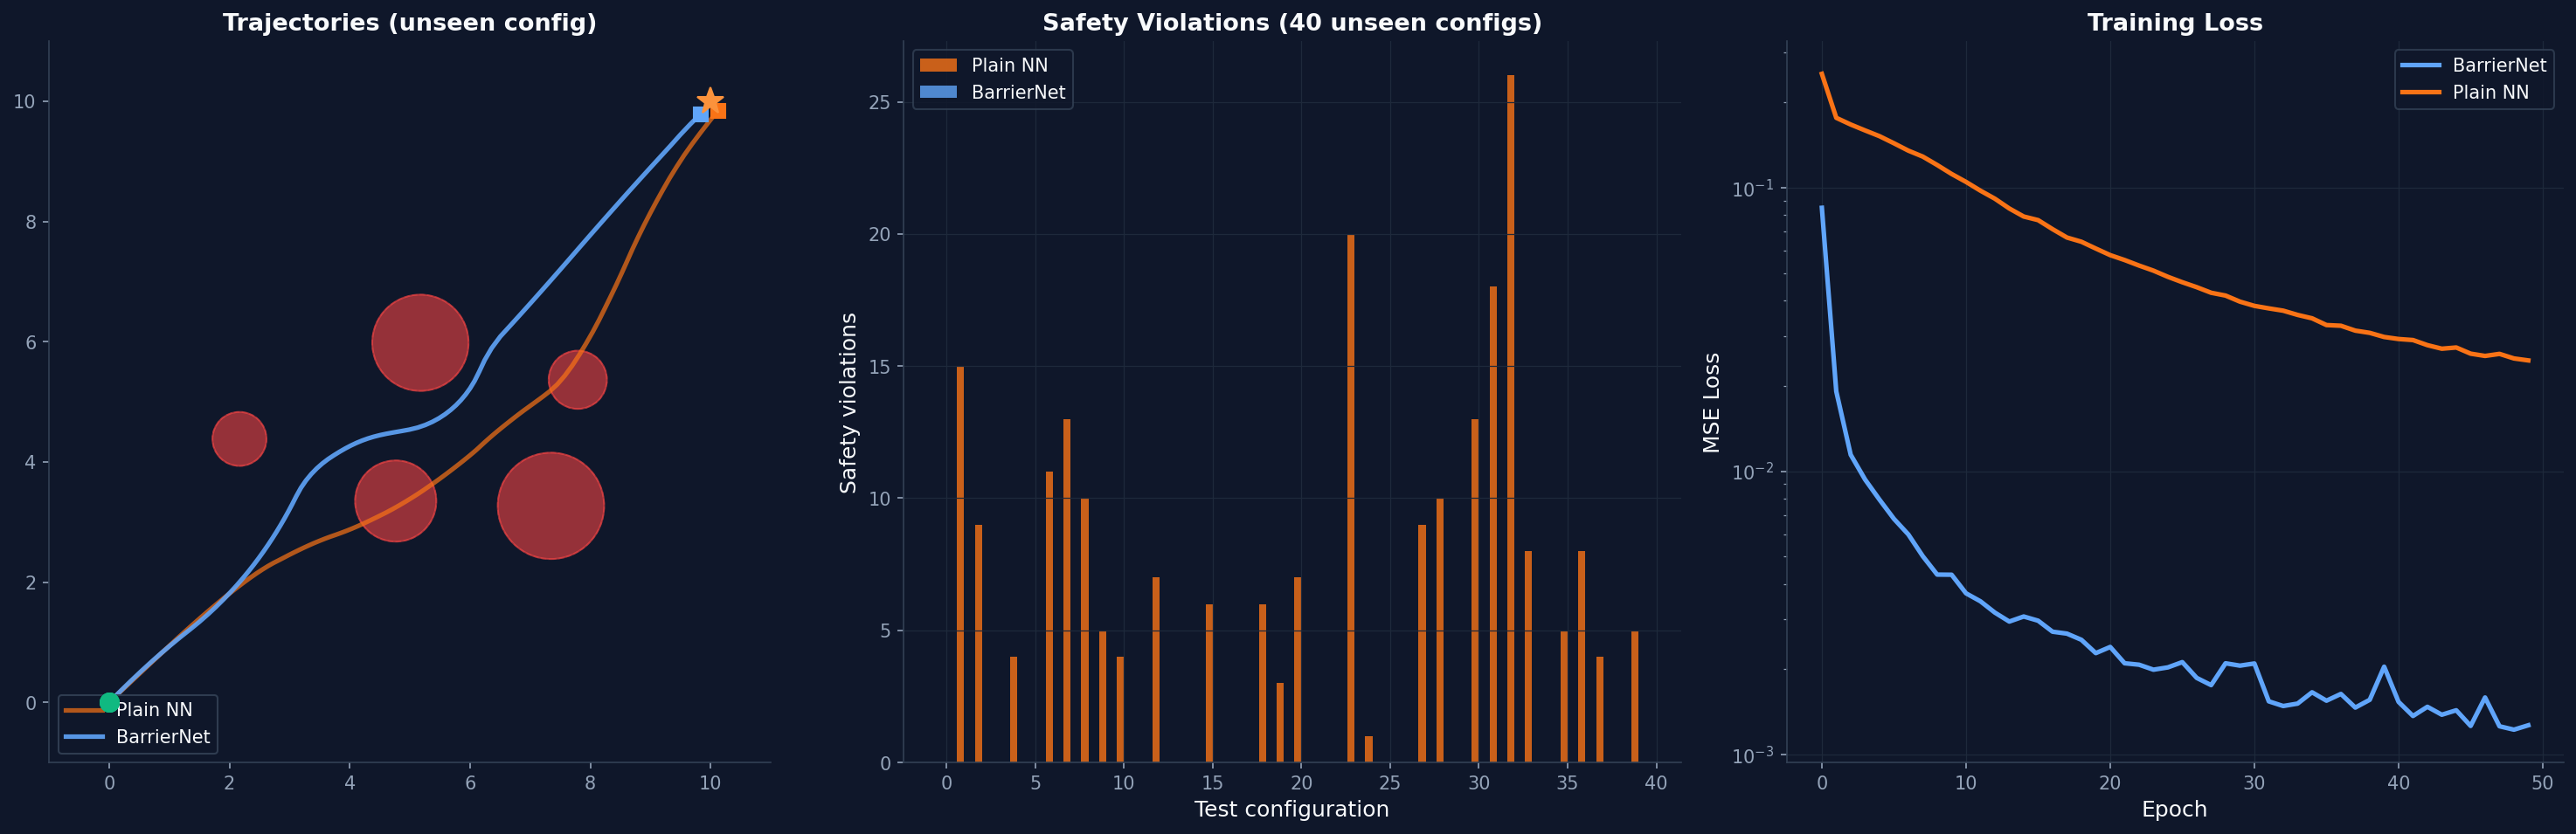

Saved hero image to ../assets/safety_filter.png


In [7]:
# --- Hero image: 3-panel, dark theme ---

def draw_obstacles(ax, obs_c, obs_r, alpha=0.6):
    for i in range(len(obs_c)):
        circle = Circle(obs_c[i], obs_r[i], color=MOREAU_COLORS['danger'],
                        alpha=alpha, zorder=3)
        ax.add_patch(circle)
        boundary = Circle(obs_c[i], obs_r[i], fill=False,
                          edgecolor=MOREAU_COLORS['danger'], linestyle='--',
                          linewidth=0.8, alpha=0.4, zorder=3)
        ax.add_patch(boundary)


def draw_trajectory(ax, positions, color, label, linewidth=2.5, alpha=0.9):
    ax.plot(positions[:, 0], positions[:, 1], color=color, linewidth=linewidth,
            alpha=alpha, zorder=5, label=label)
    ax.plot(positions[0, 0], positions[0, 1], 'o', color=MOREAU_COLORS['success'],
            markersize=10, zorder=6)
    ax.plot(positions[-1, 0], positions[-1, 1], 's', color=color,
            markersize=8, zorder=6)


def setup_workspace(ax):
    ax.set_xlim(ws_lo, ws_hi)
    ax.set_ylim(ws_lo, ws_hi)
    ax.set_aspect('equal')
    ax.plot(*start, 'o', color=MOREAU_COLORS['success'], markersize=10, zorder=6)
    ax.plot(*goal, '*', color=MOREAU_COLORS['accent_light'], markersize=15, zorder=6)
    ax.grid(False)


# Find a test config where PlainNN crashes but BarrierNet is safe
crash_idx = None
for i in range(len(test_configs)):
    if results_plain[i]['violations'] > 0 and results_barrier[i]['violations'] == 0:
        crash_idx = i
        break
if crash_idx is None:
    crash_idx = 0

set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

# Panel 1: Trajectories on a test config
ax = axes[0]
obs_c, obs_r = test_configs[crash_idx]
draw_obstacles(ax, obs_c, obs_r)
draw_trajectory(ax, results_plain[crash_idx]['positions'],
                MOREAU_COLORS['accent'], 'Plain NN', linewidth=2.5, alpha=0.7)
draw_trajectory(ax, results_barrier[crash_idx]['positions'],
                MOREAU_COLORS['primary_light'], 'BarrierNet', linewidth=2.5)
setup_workspace(ax)
ax.set_title('Trajectories (unseen config)', fontsize=13)
ax.legend(loc='lower left', fontsize=10, frameon=True,
          facecolor=MOREAU_COLORS['bg_dark'], edgecolor='#334155', framealpha=0.9)

# Panel 2: Safety violations bar chart
ax = axes[1]
per_config_viol_plain = [r['violations'] for r in results_plain]
per_config_viol_barrier = [r['violations'] for r in results_barrier]
x_pos = np.arange(len(test_configs))
ax.bar(x_pos - 0.2, per_config_viol_plain, 0.4, color=MOREAU_COLORS['accent'],
       alpha=0.8, label='Plain NN')
ax.bar(x_pos + 0.2, per_config_viol_barrier, 0.4, color=MOREAU_COLORS['primary_light'],
       alpha=0.8, label='BarrierNet')
ax.set_xlabel('Test configuration')
ax.set_ylabel('Safety violations')
ax.set_title('Safety Violations (40 unseen configs)', fontsize=13)
ax.legend(fontsize=10, frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155')

# Panel 3: Training curves
ax = axes[2]
ax.semilogy(losses_barrier, color=MOREAU_COLORS['primary_light'], linewidth=2.5,
            label='BarrierNet')
ax.semilogy(losses_plain, color=MOREAU_COLORS['accent'], linewidth=2.5,
            label='Plain NN')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss', fontsize=13)
ax.legend(fontsize=10, frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155')

plt.tight_layout()
plt.savefig('../assets/safety_filter.png', bbox_inches='tight',
            facecolor=MOREAU_COLORS['bg_dark'])
plt.show()
set_moreau_style()
print("Saved hero image to ../assets/safety_filter.png")

## Animation

Watch BarrierNet navigate an unseen obstacle field. The **dashed arrow** shows the network's nominal control `u_nom`, the **solid arrow** shows the QP-filtered safe control `u_safe`. When the arrows diverge, the safety layer is intervening.

Saved 81-frame animation to ../assets/safety_filter_anim.gif



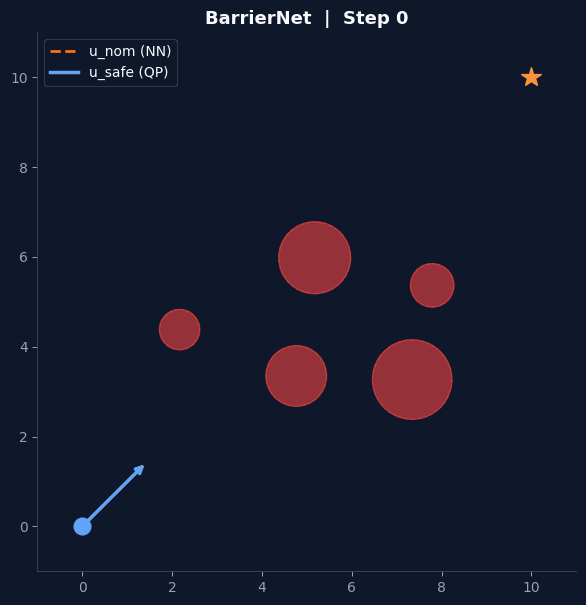

In [8]:
# --- Animation: BarrierNet navigating an unseen obstacle field ---
set_moreau_dark_style()

# Pick a config with interesting safety interventions
anim_idx = crash_idx
obs_c_anim, obs_r_anim = test_configs[anim_idx]
res_anim = results_barrier[anim_idx]
positions_anim = res_anim['positions']
controls_anim = res_anim['controls']
u_noms_anim = res_anim['u_noms']

n_trail = 8  # fading trail length
arrow_scale = 0.8

frames = []
for t in range(len(controls_anim)):
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_obstacles(ax, obs_c_anim, obs_r_anim)

    # Fading trail
    t_start = max(0, t - n_trail)
    for s in range(t_start, t):
        fade = 0.2 + 0.8 * (s - t_start) / max(t - t_start, 1)
        ax.plot(positions_anim[s:s+2, 0], positions_anim[s:s+2, 1],
                color=MOREAU_COLORS['primary_light'], linewidth=2.5, alpha=fade, zorder=4)

    # Robot position
    px, py = positions_anim[t]
    ax.plot(px, py, 'o', color=MOREAU_COLORS['primary_light'], markersize=12, zorder=7)

    # u_nom arrow (dashed)
    if u_noms_anim is not None:
        ax.annotate('', xy=(px + arrow_scale * u_noms_anim[t, 0],
                            py + arrow_scale * u_noms_anim[t, 1]),
                    xytext=(px, py),
                    arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['accent'],
                                   linewidth=2, linestyle='--'))

    # u_safe arrow (solid)
    ax.annotate('', xy=(px + arrow_scale * controls_anim[t, 0],
                        py + arrow_scale * controls_anim[t, 1]),
                xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['primary_light'],
                                linewidth=2.5))

    setup_workspace(ax)
    ax.set_title(f'BarrierNet  |  Step {t}', fontsize=13)

    # Legend
    ax.plot([], [], '--', color=MOREAU_COLORS['accent'], linewidth=2, label='u_nom (NN)')
    ax.plot([], [], '-', color=MOREAU_COLORS['primary_light'], linewidth=2.5, label='u_safe (QP)')
    ax.legend(loc='upper left', fontsize=10, frameon=True,
              facecolor=MOREAU_COLORS['bg_dark'], edgecolor='#334155', framealpha=0.9)

    frames.append(fig_to_pil(fig))
    plt.close(fig)

gif_path = '../assets/safety_filter_anim.gif'
save_gif(frames, gif_path, fps=8)
print(f"Saved {len(frames)}-frame animation to {gif_path}")
display_gif(gif_path)

---

**Key takeaways:**

| | Plain NN | BarrierNet |
|---|---|---|
| **Architecture** | MLP &rarr; u | MLP &rarr; (u_nom, &alpha;) &rarr; QP &rarr; u_safe |
| **Safety guarantee** | None | By construction (QP) |
| **Unseen configs** | May crash | Always safe |
| **Training** | MSE | MSE through differentiable QP (Moreau) |

- **Moreau as a neural network layer** &mdash; the QP is embedded inside the forward pass, and implicit differentiation of KKT conditions provides exact gradients for the backward pass
- **Safety is architectural, not learned** &mdash; the CBF-QP layer guarantees constraint satisfaction regardless of what the MLP outputs
- **Batched oracle** &mdash; training data is generated by a batched safety-filter QP (also solved by Moreau), simulating 400 obstacle configurations in parallel